In [1]:
# Libs
from time import gmtime, strftime
import xarray as xr
import numpy as np

# Locals
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
import oggm.cfg as cfg
from oggm.shop import gcm_climate

In [2]:
import xarray as xr

with xr.open_dataset('/home/usman/Music/GeeMap/Results/15_GCM_projections.nc') as ds:
    ds_merged = ds


In [8]:
print(ds_merged)

<xarray.Dataset> Size: 14MB
Dimensions:                       (SCENARIO: 3, GCM: 5, time: 87, rgi_id: 15,
                                   month_2d: 12)
Coordinates:
  * time                          (time) float64 696B 2.015e+03 ... 2.101e+03
  * rgi_id                        (rgi_id) <U14 840B 'RGI60-14.01202' ... 'RG...
    hydro_year                    (time) int64 696B ...
    hydro_month                   (time) int64 696B ...
    calendar_year                 (time) int64 696B ...
    calendar_month                (time) int64 696B ...
  * month_2d                      (month_2d) int64 96B 1 2 3 4 5 ... 9 10 11 12
    calendar_month_2d             (month_2d) int64 96B ...
  * GCM                           (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'u...
  * SCENARIO                      (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Data variables: (12/24)
    volume                        (SCENARIO, GCM, time, rgi_id) float64 157kB ...
    volume_bsl                    (SCENARIO

In [6]:
ds_total_volume = ds_merged['volume'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          skipna=True,  # ignore nan values
                                          # important, we need values for every glacier (here 2) to do the sum
                                          # if some have NaN, the sum should also be NaN (if you don't set min_count, the sum will be 0, which is bad)
                                          min_count=len(ds_merged.rgi_id), 
                                          keep_attrs=True)  # keep the variable descriptions   


In [7]:
print(ds_total_volume)

<xarray.DataArray 'volume' (SCENARIO: 3, GCM: 5, time: 87)> Size: 10kB
array([[[2.28378759e+10, 2.27093644e+10, 2.24062053e+10, ...,
         1.45785569e+10, 1.45124367e+10, 1.44381602e+10],
        [2.28378759e+10, 2.28834319e+10, 2.28707405e+10, ...,
         1.55214568e+10, 1.55888835e+10, 1.56582199e+10],
        [2.28378759e+10, 2.26241114e+10, 2.25161644e+10, ...,
         1.81344728e+10, 1.81334357e+10, 1.81459807e+10],
        [2.28378759e+10, 2.27175885e+10, 2.26686245e+10, ...,
         1.77462168e+10, 1.78245268e+10, 1.77091471e+10],
        [2.28378759e+10, 2.27150141e+10, 2.27776742e+10, ...,
         9.74868830e+09, 9.71593213e+09, 9.47052830e+09]],

       [[2.28378759e+10, 2.28198519e+10, 2.28774798e+10, ...,
         1.02381624e+10, 1.00512011e+10, 9.98844664e+09],
        [2.28378759e+10, 2.26990058e+10, 2.25574137e+10, ...,
         9.50020962e+09, 9.26569046e+09, 8.86365619e+09],
        [2.28378759e+10, 2.26102241e+10, 2.26312759e+10, ...,
         1.02739747e+10, 

In [5]:
# perfect, now, the `NaN` is preserved!
assert np.all(np.isnan(ds_total_volume.sel(SCENARIO='ssp370').sel(GCM='mpi-esm1-2-hr_r1i1p1f1')))

AssertionError: 

In [8]:
ds_total_volume_median = ds_total_volume.median(dim='GCM',  # over which dimension the median should be calculated
                                            skipna=True,  # ignore nan values
                                            keep_attrs=True)  # keep all variable descriptions
ds_total_volume_median

<xarray.DataArray 'volume' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.28378759e+10, 2.27150141e+10, 2.26686245e+10, 2.25338757e+10,
        2.23617194e+10, 2.23566408e+10, 2.22924305e+10, 2.22660184e+10,
        2.21384624e+10, 2.20502167e+10, 2.19019284e+10, 2.18610951e+10,
        2.16353722e+10, 2.16373808e+10, 2.15175831e+10, 2.14760571e+10,
        2.13089542e+10, 2.11044693e+10, 2.10284080e+10, 2.09101952e+10,
        2.07321167e+10, 2.05362434e+10, 2.05137022e+10, 2.03108746e+10,
        2.02089792e+10, 2.01309598e+10, 2.00391732e+10, 2.01946458e+10,
        2.02408361e+10, 2.03158306e+10, 2.02068250e+10, 2.00190084e+10,
        1.97226721e+10, 1.96944160e+10, 1.96022976e+10, 1.94832389e+10,
        1.93446676e+10, 1.92023733e+10, 1.91152482e+10, 1.91080078e+10,
        1.90095092e+10, 1.90236248e+10, 1.89431588e+10, 1.88439665e+10,
        1.87293044e+10, 1.86095325e+10, 1.84098128e+10, 1.84074420e+10,
        1.82604545e+10, 1.82895243e+10, 1.82053050e+10, 1.81267116e+10,
        1.80981415e+10, 1.82155327e+10, 1.81820435e+10, 1.81664629e+10,
        1.80807873e+10, 1.79438090e+10, 1.78778159e+10, 1.77806044e+10,
        1.77396332e+10, 1.76311381e+10, 1.74877177e+10, 1.73951726e+10,
        1.72303782e+10, 1.70799189e+10, 1.70663034e+10, 1.69266586e+10,
        1.67894799e+10, 1.69294352e+10, 1.67901567e+10, 1.65754277e+10,
        1.64249583e+10, 1.63727511e+10, 1.63811758e+10, 1.63769619e+10,
        1.64652927e+10, 1.61107552e+10, 1.60072037e+10, 1.58399736e+10,
...
        2.22523229e+10, 2.21283267e+10, 2.19568598e+10, 2.16595540e+10,
        2.14879820e+10, 2.13077212e+10, 2.11757775e+10, 2.10189423e+10,
        2.11720642e+10, 2.11043163e+10, 2.09669246e+10, 2.08112965e+10,
        2.06721806e+10, 2.03549722e+10, 2.01171706e+10, 1.99963147e+10,
        1.96656883e+10, 1.95535316e+10, 1.94013015e+10, 1.93053006e+10,
        1.92557914e+10, 1.92607748e+10, 1.91001405e+10, 1.89278820e+10,
        1.87947006e+10, 1.87084015e+10, 1.84378390e+10, 1.83185485e+10,
        1.82363948e+10, 1.81151340e+10, 1.77710343e+10, 1.77558465e+10,
        1.74905538e+10, 1.73028158e+10, 1.71552737e+10, 1.71212158e+10,
        1.69275116e+10, 1.65659961e+10, 1.62437543e+10, 1.62127958e+10,
        1.59893140e+10, 1.56971111e+10, 1.56957915e+10, 1.55860289e+10,
        1.53860893e+10, 1.50953705e+10, 1.50317449e+10, 1.49879141e+10,
        1.46745848e+10, 1.45723330e+10, 1.45747663e+10, 1.45502259e+10,
        1.42639423e+10, 1.39323119e+10, 1.36601804e+10, 1.35252204e+10,
        1.32025095e+10, 1.28689885e+10, 1.26664024e+10, 1.25802065e+10,
        1.24082067e+10, 1.20605901e+10, 1.19419339e+10, 1.15701908e+10,
        1.13261390e+10, 1.09301309e+10, 1.06811972e+10, 1.04090696e+10,
        1.02597796e+10, 1.00456298e+10, 9.77191357e+09, 9.39096230e+09,
        9.12911620e+09, 8.88703693e+09, 8.58996513e+09, 8.49669327e+09,
        8.33448628e+09, 8.04901609e+09, 7.76032326e+09]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier volume
    unit:         m 3

In [9]:
import matplotlib.pyplot as plt

In [10]:
# estimate the minimum volume for each time step and scenario over the GCMs
ds_total_volume_min = ds_total_volume.min(dim='GCM', keep_attrs=True,skipna=True)
# estimate the 25th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p25 = ds_total_volume.quantile(0.25, dim='GCM', keep_attrs=True,skipna=True)
# estimate the 50th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p50 = ds_total_volume.quantile(0.5, dim='GCM', keep_attrs=True,skipna=True)
# this is the same as the median -> Let's check
np.testing.assert_allclose(ds_total_volume_median,ds_total_volume_p50)
# estimate the 75th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p75 = ds_total_volume.quantile(0.75, dim='GCM', keep_attrs=True,skipna=True)
# estimate the maximum volume for each time step and scenario over the GCMs
ds_total_volume_max = ds_total_volume.max(dim='GCM', keep_attrs=True,skipna=True)

# Think twice if it is appropriate to compute a mean/std over your GCM sample, is it Gaussian distributed?
# Otherwise use instead median and percentiles or total range
ds_total_volume_mean = ds_total_volume.mean(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_std = ds_total_volume.std(dim='GCM', keep_attrs=True,
                                            skipna=True)

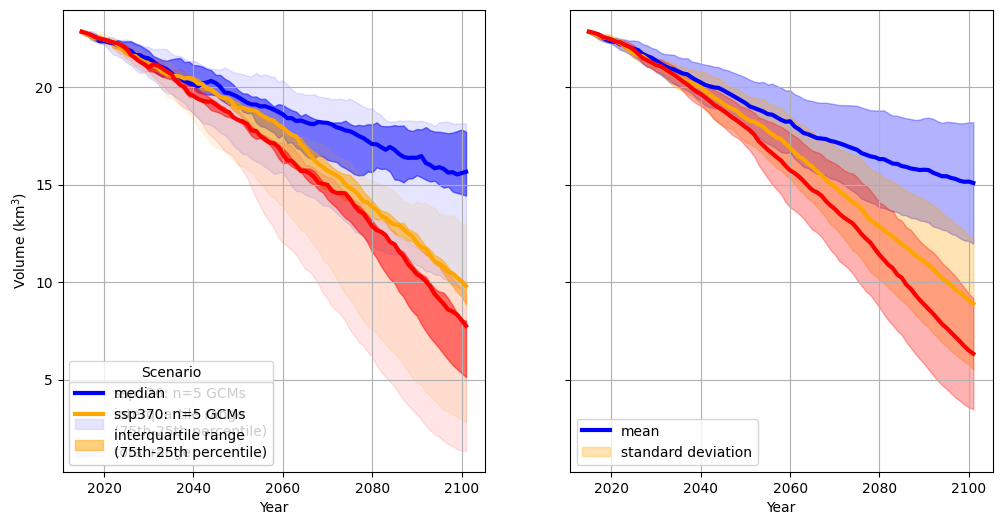

In [11]:
color_dict={'ssp126':'blue', 'ssp370':'orange', 'ssp585':'red'}


fig, axs = plt.subplots(1,2, figsize=(12,6), 
                        sharey=True # we want to share the y axis betweeen the subplots
                       )
for scenario in color_dict.keys():
    # get amount of GCMs per Scenario to add it to the legend:
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario)/1e9,  # m3 -> km3
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario],lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario)/1e9,
                        color=color_dict[scenario],
                        alpha=0.5,
                        label='interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario)/1e9,
                        color=color_dict[scenario],
                        alpha=0.1,
                        label='total range')


for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                 ds_total_volume_mean.sel(SCENARIO=scenario)/1e9,  # m3 -> km3
                 color=color_dict[scenario],
                 label='mean',lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario)/1e9 - ds_total_volume_std.sel(SCENARIO=scenario)/1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario)/1e9 + ds_total_volume_std.sel(SCENARIO=scenario)/1e9,
                        alpha=0.3,
                        color=color_dict[scenario],
                       label='standard deviation')
    
for ax in axs:
    # get all handles and labels and then create two different legends
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # we want to have two legends, let's save the first one
        # which just shows the colors and the different SSPs here 
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario') 
        ax.set_ylabel(r'Volume (km$^3$)')
        # create the second one, that shows the different statistical estimates
        ax.legend([handles[0],handles[3],handles[4]],
                  ['median',labels[3],labels[4]], loc='lower left')
        # we need to allow for two legend, this is done like that
        ax.add_artist(leg1)
    else:
        # for the second plot, we only want to have the legend for mean and std
        ax.legend(handles[::3], labels[::3], loc='lower left') 
    ax.set_xlabel('Year');
    ax.grid()

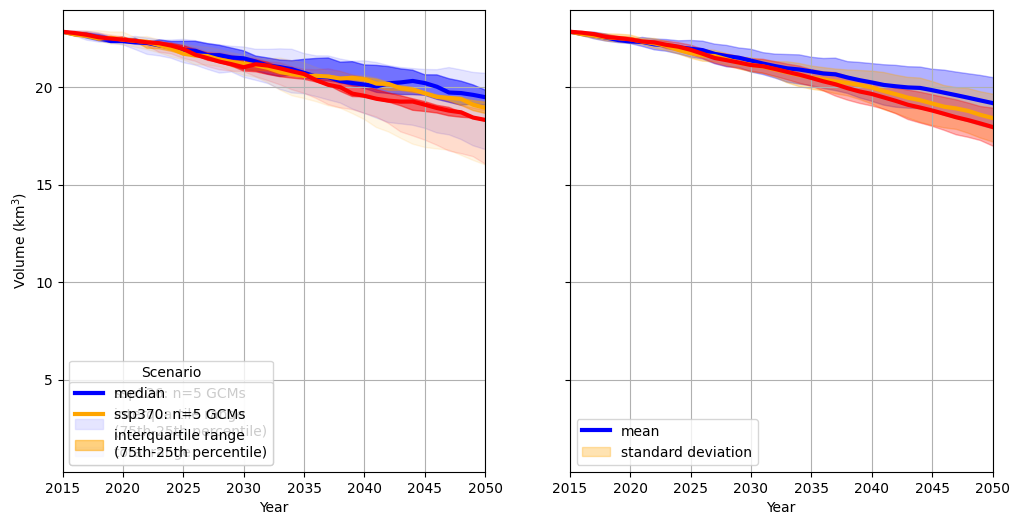

In [12]:
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

for scenario in color_dict.keys():
    # Get the amount of GCMs per scenario to add it to the legend
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # m³ -> km³
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario],
                        alpha=0.5,
                        label='interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario],
                        alpha=0.1,
                        label='total range')

for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # m³ -> km³
                color=color_dict[scenario],
                label='mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3,
                        color=color_dict[scenario],
                        label='standard deviation')

for ax in axs:
    # Set the x-axis limit to bound time to 2050
    ax.set_xlim([ds_total_volume_mean.time.min().values, 2050])

    # Get all handles and labels and then create two different legends
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # Save the first legend (shows colors and SSPs)
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario') 
        ax.set_ylabel(r'Volume (km$^3$)')
        # Create the second legend (shows statistical estimates)
        ax.legend([handles[0], handles[3], handles[4]],
                  ['median', labels[3], labels[4]], loc='lower left')
        # Allow two legends
        ax.add_artist(leg1)
    else:
        # For the second plot, show only the legend for mean and std
        ax.legend(handles[::3], labels[::3], loc='lower left')
    ax.set_xlabel('Year')
    ax.grid()


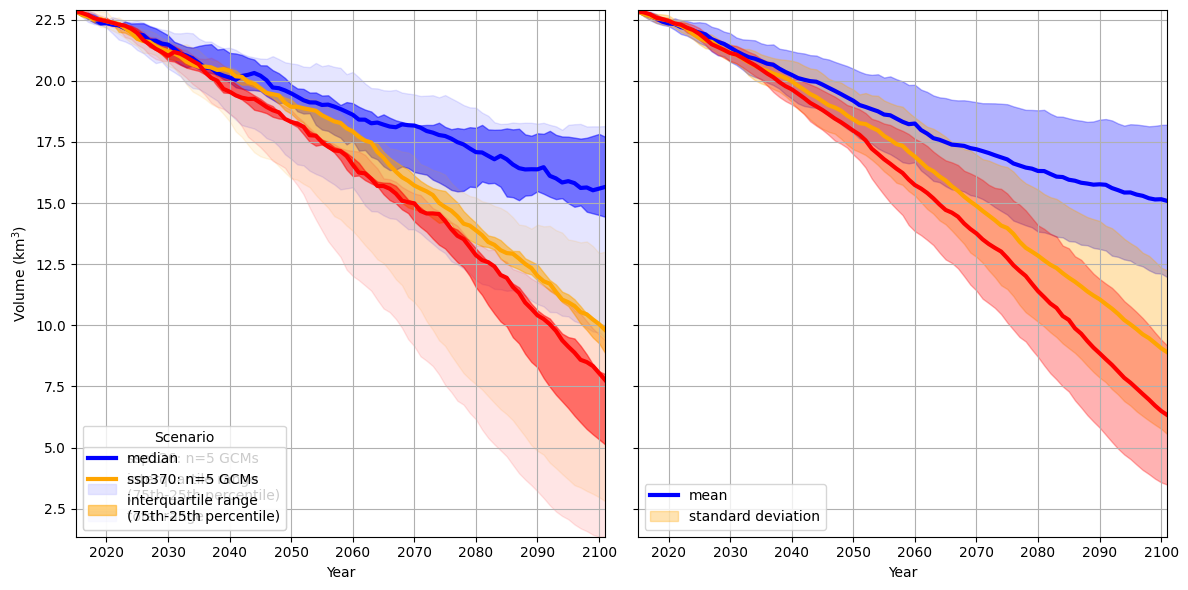

In [16]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='total range')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label='mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario], label='standard deviation')

# Adjust axis limits dynamically to fit the data perfectly
for ax in axs:
    # Set x-axis limits based on data time range
    ax.set_xlim([ds_total_volume_mean.time.min().values, ds_total_volume_mean.time.max().values])
    
    # Set y-axis limits based on minimum and maximum values across all scenarios
    y_min = ds_total_volume_min.min().values / 1e9  # Convert to km³
    y_max = ds_total_volume_max.max().values / 1e9  # Convert to km³
    ax.set_ylim([y_min, y_max])
    
    # Get handles and labels for the legends
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # First legend: Colors and SSPs
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario')
        ax.set_ylabel(r'Volume (km$^3$)')
        # Second legend: Statistical estimates
        ax.legend([handles[0], handles[3], handles[4]],
                  ['median', labels[3], labels[4]], loc='lower left')
        ax.add_artist(leg1)  # Allow two legends
    else:
        # Second plot: Mean and standard deviation
        ax.legend(handles[::3], labels[::3], loc='lower left')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Show the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/projection.png', dpi=500, bbox_inches='tight')
plt.show()


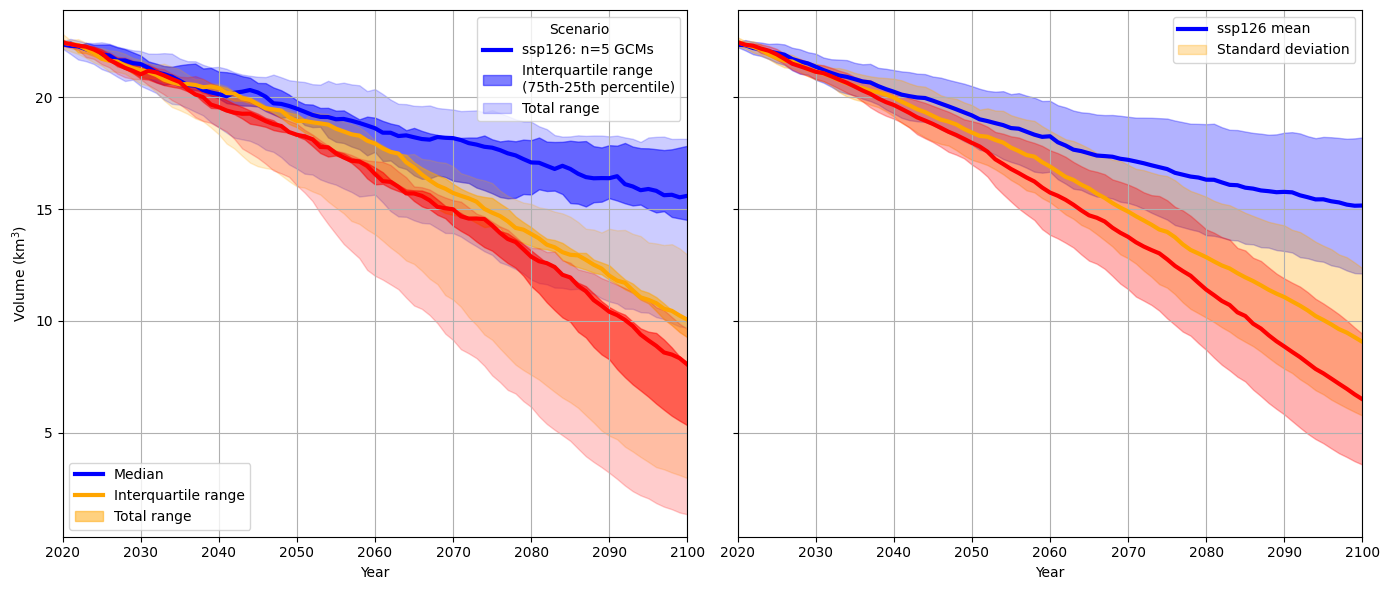

In [19]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)  # Adjust width for better spacing

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.2,
                        label='Total range')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario} mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario], label='Standard deviation')

# Adjust axis limits for clear visualization
for ax in axs:
    # Set x-axis limits to encompass the entire data range
    ax.set_xlim([2020, 2100])
    
    # Dynamically set y-axis limits with a small margin
    y_min = ds_total_volume_min.min().values / 1e9 - 1  # Add margin
    y_max = ds_total_volume_max.max().values / 1e9 + 1  # Add margin
    ax.set_ylim([y_min, y_max])
    
    # Configure legend and labels
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # First subplot legend for scenarios and ranges
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario', loc='upper right')
        ax.set_ylabel(r'Volume (km$^3$)')
        ax.legend([handles[0], handles[3], handles[4]],
                  ['Median', 'Interquartile range', 'Total range'], loc='lower left')
        ax.add_artist(leg1)  # Allow two legends
    else:
        # Second subplot legend for mean and standard deviation
        ax.legend(handles[::3], labels[::3], loc='upper right')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and show the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/projection_2020_2100.png', dpi=500, bbox_inches='tight')
plt.show()


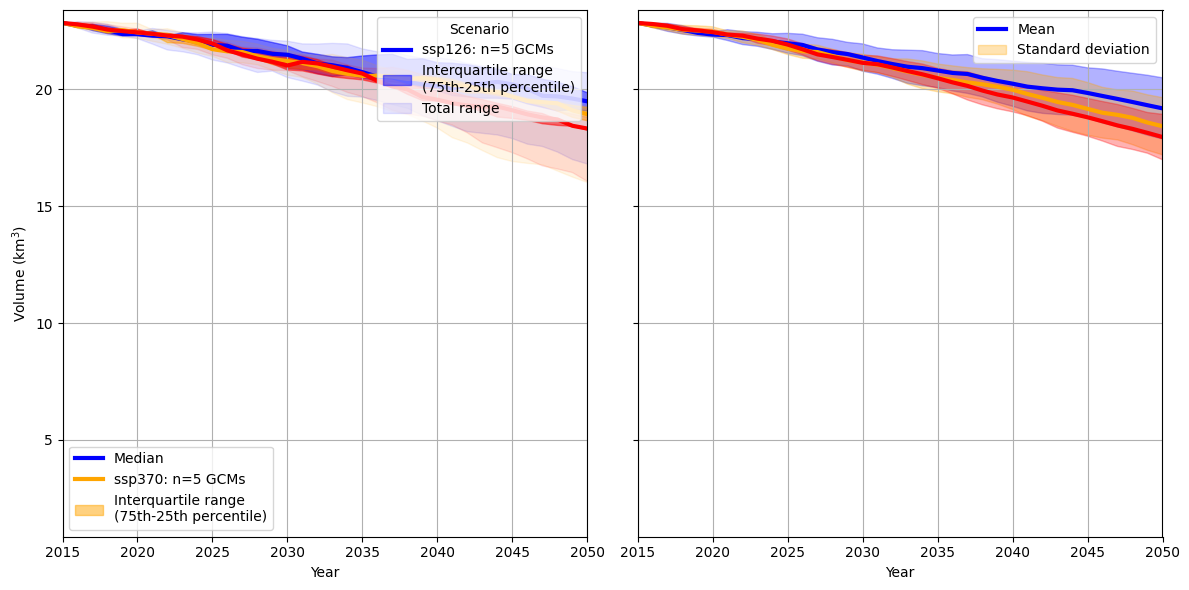

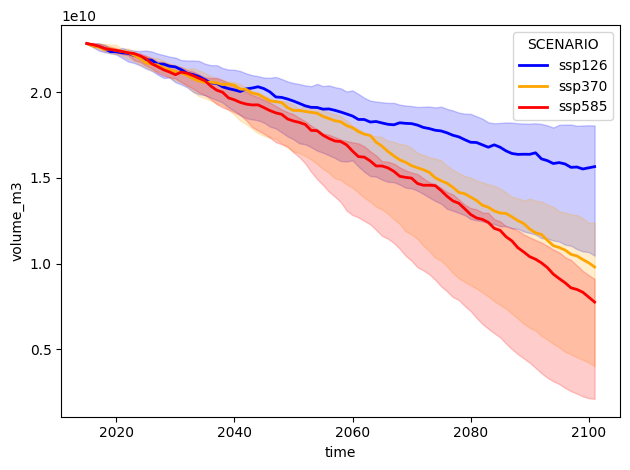

In [21]:
import seaborn as sns 
# this code might only work with seaborn v>=0.12
# seaborn always likes to have pandas dataframes
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()
sns.lineplot(x='time', y='volume_m3',
             hue='SCENARIO', # these are the dimension for the different colors 
             estimator='median', # here you could also choose the mean
             data=pd_total_volume,
             lw=2, # increase the linewidth a bit
             palette= color_dict, # let's use the same colors as before
             # for errorbar you could also choose another percentile range
             # see: https://seaborn.pydata.org/tutorial/error_bars.html
             # "90" means the range goes from the 5th to the 95th percentile
             # (50 would be the interquartile range, i.e., the same as two plots above)
             errorbar=('pi', 90) 
            );
# Save and show the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/SSPprojection_2020_2100.png', dpi=500, bbox_inches='tight')
plt.show()


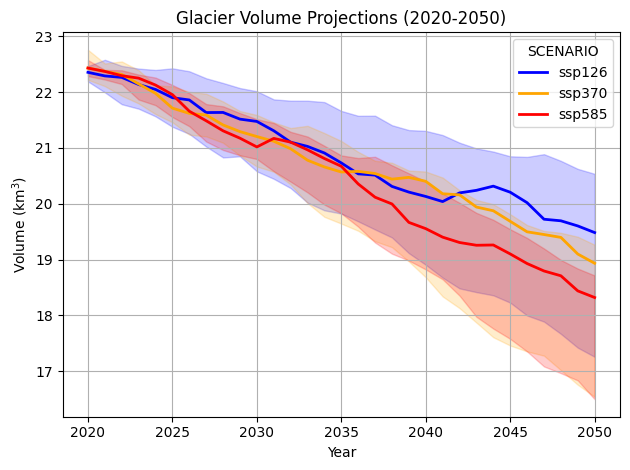

In [22]:
import seaborn as sns
import pandas as pd

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2050
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2020) & (pd_total_volume['time'] <= 2050)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projections (2020-2050)')
plt.grid(True)
plt.tight_layout()

plt.savefig('/home/usman/Music/GeeMap/Results/2050projection_2020_2100.png', dpi=500, bbox_inches='tight')
plt.show()


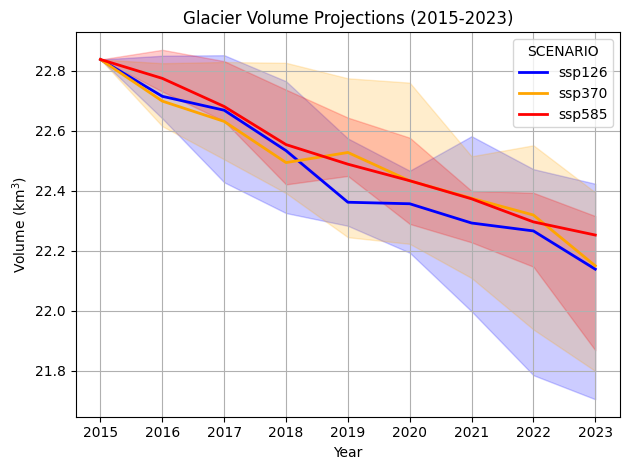

In [28]:
import seaborn as sns
import pandas as pd

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2050
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2015) & (pd_total_volume['time'] <= 2023)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projections (2015-2023)')
plt.grid(True)
plt.tight_layout()

plt.savefig('/home/usman/Music/GeeMap/Results/2050projection_2015_2023.png', dpi=500, bbox_inches='tight')
plt.show()


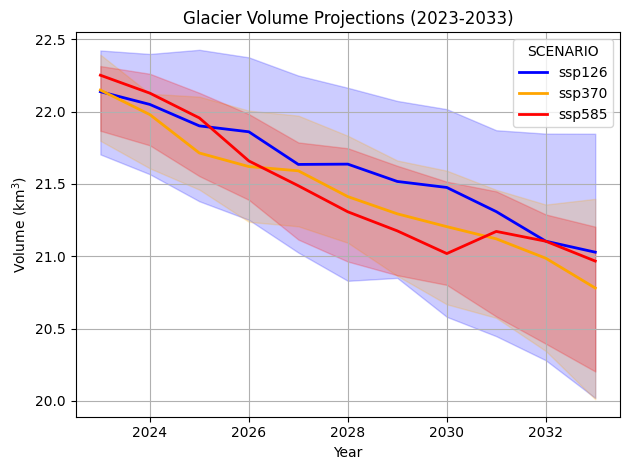

In [27]:
import seaborn as sns
import pandas as pd

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2050
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2023) & (pd_total_volume['time'] <= 2033)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projections (2023-2033)')
plt.grid(True)
plt.tight_layout()

plt.savefig('/home/usman/Music/GeeMap/Results/2050projection_2023_2033.png', dpi=500, bbox_inches='tight')
plt.show()


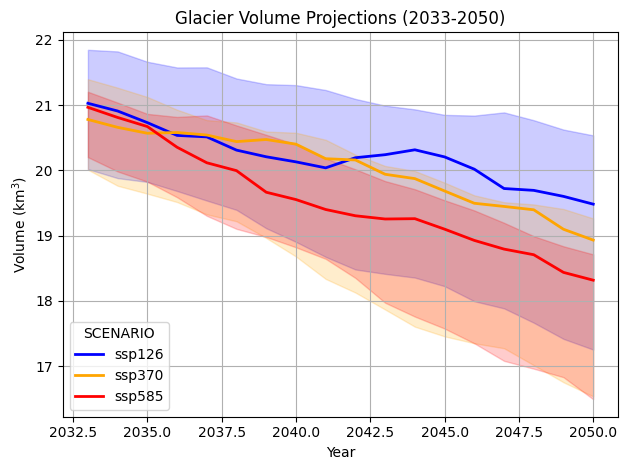

In [26]:
import seaborn as sns
import pandas as pd

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2050
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2033) & (pd_total_volume['time'] <= 2050)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projections (2033-2050)')
plt.grid(True)
plt.tight_layout()

plt.savefig('/home/usman/Music/GeeMap/Results/2050projection_2033_2050.png', dpi=500, bbox_inches='tight')
plt.show()
